# Conteo automatico de colonias con CellSAM

Analisis de quince fotografias de placas tomadas en laboratorio, procesadas con CellSAM sobre un pipeline adaptado a las condiciones reales de captura.

Las fotos se tomaron sobre transiluminador, una placa por imagen, con la muestra y la fecha rotuladas a marcador en el borde de la placa. Esas dos caracteristicas de la captura, el contraluz y la rotulacion, son las que obligaron a adaptar el pipeline y determinan casi todo lo que se explica aqui.

Este documento es de lectura. No hace falta ejecutar nada, los resultados ya estan calculados e incrustados.

## 1. El metodo

El procesamiento de cada fotografia sigue cinco pasos.

**Deteccion de la placa.** Se localiza el disco de la placa con transformada de Hough sobre la imagen desenfocada y se recorta, enmascarando todo lo que queda fuera del circulo.

**Recorte del borde al 86 por ciento del radio.** El borde de la placa concentra tres cosas que no son colonias, la rotulacion a marcador, el menisco del agar y la condensacion. El margen no se eligio a ojo, se midio donde cae cada cosa. Las colonias reales llegan hasta el 78 por ciento del radio y los artefactos de borde empiezan en el 89 por ciento, asi que el corte al 86 por ciento cae limpiamente en medio.

**Correccion de iluminacion.** El transiluminador deja un gradiente fuerte, con un punto caliente en el centro y viñeteo hacia el borde. Se estima el fondo con un desenfoque gaussiano de sigma grande y se divide la imagen por el, con lo que queda solo la estructura de alta frecuencia, es decir las colonias. Despues se aplica CLAHE para realzar el contraste local.

**Estimacion previa de densidad.** Un paso rapido de vision clasica, con umbral adaptativo y morfologia, estima cuantas colonias hay antes de llamar al modelo, con la idea de decidir con que sensibilidad correr CellSAM. Conviene adelantar que este paso no funciono sobre estas fotografias y en la practica quedo inactivo, lo que se detalla en la seccion de limitaciones. Salvo una placa, las quince se procesaron con el mismo umbral de 0.40.

**Segmentacion y filtrado.** CellSAM segmenta la imagen corregida y las regiones resultantes se filtran por area, por solidez y por color, este ultimo para descartar la rotulacion.

### El paso que mas importa

La correccion de iluminacion es lo que hace viable el analisis de estas fotos. Es el codigo del pipeline que conviene mirar.

```python
def corregir_iluminacion(recorte_bgr, mascara_placa):
    gris = cv2.cvtColor(recorte_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    k = int(max(recorte_bgr.shape[:2]) * 0.15) | 1   # kernel impar
    fondo = cv2.GaussianBlur(gris, (k, k), 0)
    corregida = gris / (fondo + 1e-6)

    dentro = mascara_placa > 0
    bajo, alto = np.percentile(corregida[dentro], [1, 99])
    corregida = np.clip((corregida - bajo) / (alto - bajo + 1e-6), 0, 1)
    corregida = (corregida * 255).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    corregida = clahe.apply(corregida)
    corregida[~dentro] = 0
    return cv2.cvtColor(corregida, cv2.COLOR_GRAY2BGR)
```

El pipeline completo esta en `scripts/contar_mis_fotos.py` y los experimentos que lo justifican en `scripts/exp_prepro_mis_fotos.py`.

## 2. Por que cada decision

Cada ajuste salio de un experimento medido sobre las propias fotos, no de una impresion visual.

### Correccion de iluminacion

Sin ella el modelo no detectaba nada en las placas de colonias palidas. La normalizacion interna de CellSAM es global y no corrige un gradiente de baja frecuencia como el del transiluminador.

| Imagen | sin correccion, umbral 0.65 | sin correccion, umbral 0.40 | con correccion, umbral 0.65 | con correccion, umbral 0.40 |
|---|---|---|---|---|
| M2-A-3 | 0 | 0 | 15 | 29 |
| MC73-C | 1 | 3 | 4 | 4 |
| MC73-A, control | 13 | 13 | 13 | 13 |

Dos lecturas sostienen la decision. Bajar el umbral por si solo no arregla nada, M2-A-3 se queda en cero en las dos columnas sin correccion, de modo que el problema no era la sensibilidad sino el contraste. Y el control MC73-A da 13 en las cuatro variantes, o sea que la correccion no degrada lo que ya funcionaba bien.

### Rechazo de la rotulacion

El marcador azul del borde se contaba como colonias. En una placa esteril llego a producir ocho falsos positivos. Midiendo el tono de cada region detectada aparecio una separacion limpia entre la tinta y las colonias.

| Tipo de region | Tono, hue | Radio relativo |
|---|---|---|
| Tinta azul del rotulo | 71 a 105 | 0.90 a 0.95 |
| Colonias reales | 39 a 44 | 0.10 a 0.78 |
| Menisco y condensacion del borde | 39 a 42 | 0.89 a 0.91 |

La tinta se separa por color y los artefactos del borde por posicion, que es la razon del recorte al 86 por ciento del radio.

### Filtro de area, un resultado negativo

Se sospechaba que el area minima de 300 pixeles estaba descartando las colonias mas pequeñas. Al medir la distribucion real de areas la region mas pequeña detectada resulto de 648 pixeles, mas del doble del filtro. La hipotesis era falsa y el filtro no estaba cortando nada.

Esto reubica el problema. Las colonias que faltan no se estan filtrando, es que el detector no las propone como region, de modo que el limite esta en el modelo y no se puede resolver ajustando los filtros posteriores.

## 3. Resultados

Conteo de las quince placas. La columna scout es la estimacion previa por vision clasica y la columna tinta cuenta las regiones descartadas por corresponder a la rotulacion.

| Imagen | Colonias | Scout | Umbral | Tinta descartada |
|---|---|---|---|---|
| M1-B | 0 | 84 | 0.65 | 0 |
| M1-C | 0 | 28 | 0.4 | 0 |
| M1-D | 7 | 35 | 0.4 | 1 |
| M2-A-3 | 29 | 26 | 0.4 | 0 |
| M2-A | 9 | 45 | 0.4 | 1 |
| M2-B | 1 | 36 | 0.4 | 1 |
| M2-C | 3 | 33 | 0.4 | 0 |
| MC73-A | 13 | 5 | 0.4 | 0 |
| MC73-B | 15 | 15 | 0.4 | 0 |
| MC73-C | 4 | 26 | 0.4 | 9 |
| MC73-D | 9 | 5 | 0.4 | 0 |
| RC73-A-2.5 | 243 | 7 | 0.4 | 3 |
| RC73-A-3.1 | 81 | 44 | 0.4 | 8 |
| RC73-B-2.5 | 225 | 12 | 0.4 | 8 |
| RC73-B-3.1 | 60 | 36 | 0.4 | 3 |

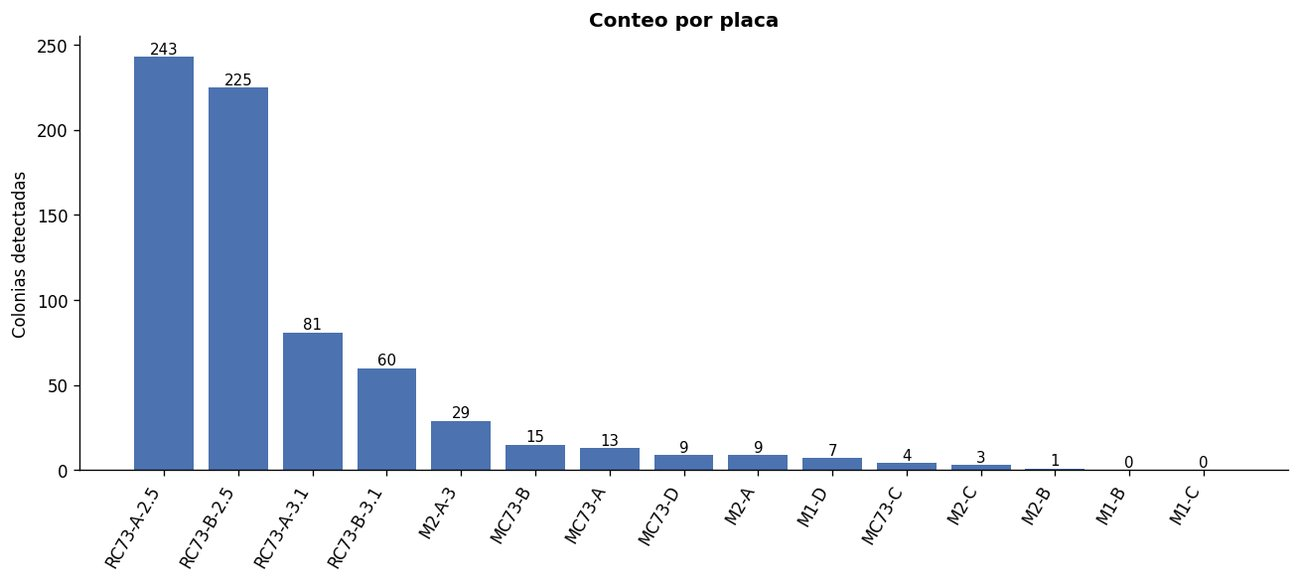

## 4. Paneles por placa

Cada panel muestra tres vistas, la placa recortada, la imagen corregida que recibe el modelo y las colonias detectadas en color.

El panel del medio es el mas util para juzgar un conteo. Si en el las colonias se ven nitidas pero el panel de la derecha las deja sin marcar, el conteo se quedo corto por limitacion del detector y no por un problema de la imagen.

### M1-B, 0 colonias detectadas

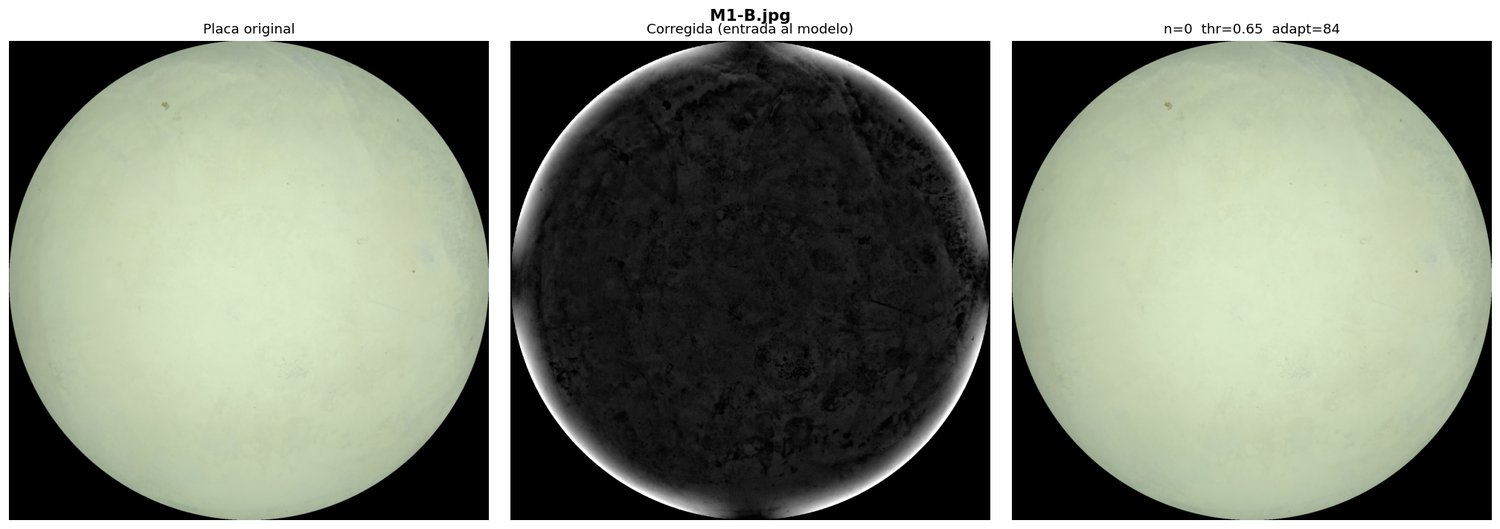

### M1-C, 0 colonias detectadas

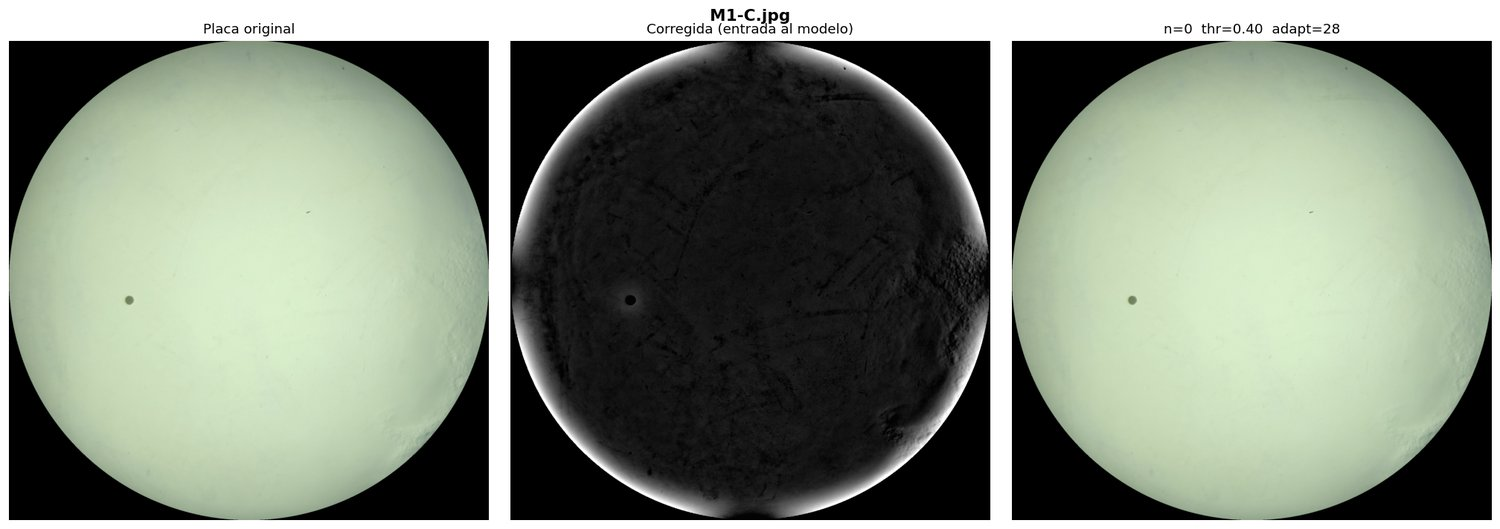

### M1-D, 7 colonias detectadas

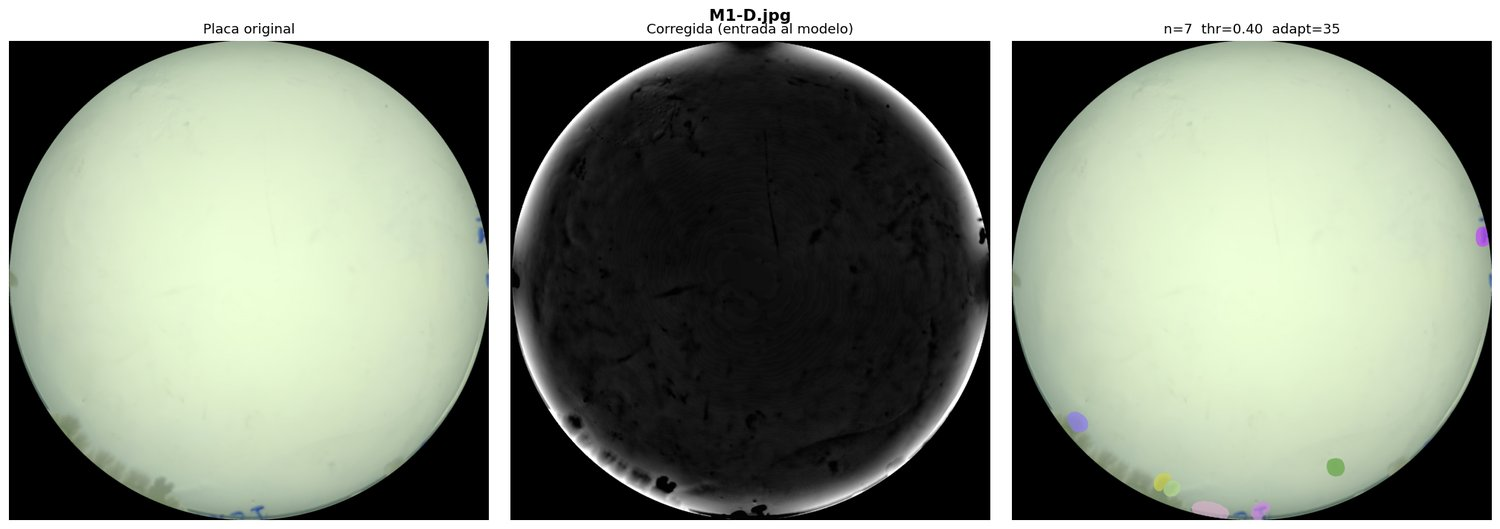

### M2-A-3, 29 colonias detectadas

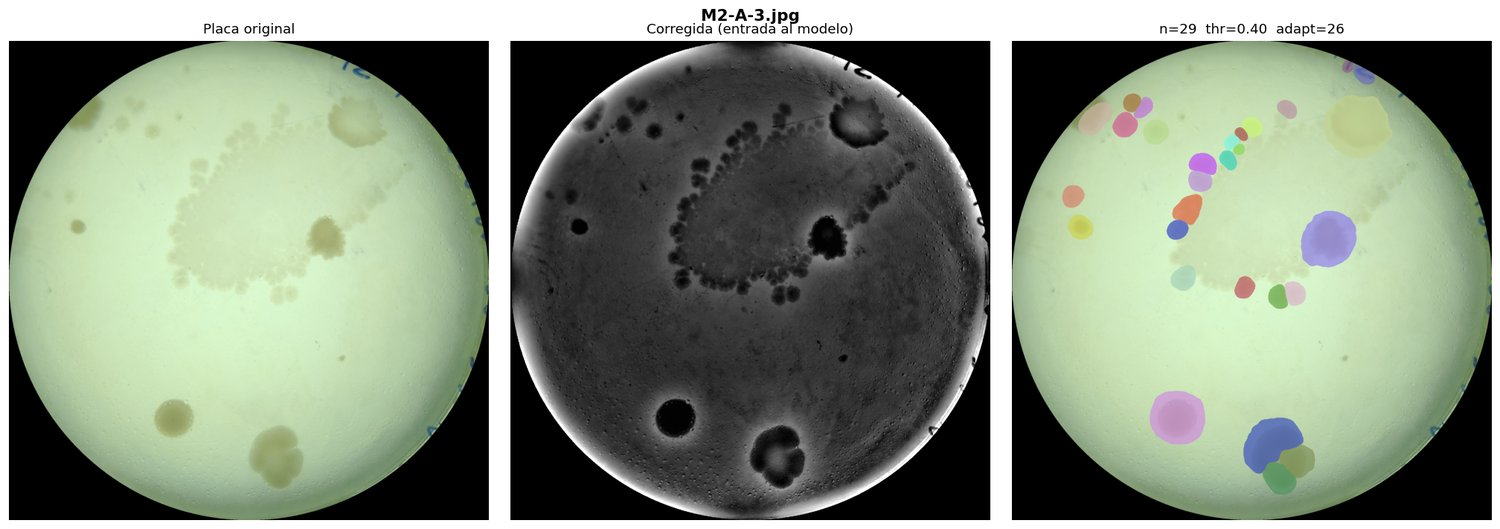

### M2-A, 9 colonias detectadas

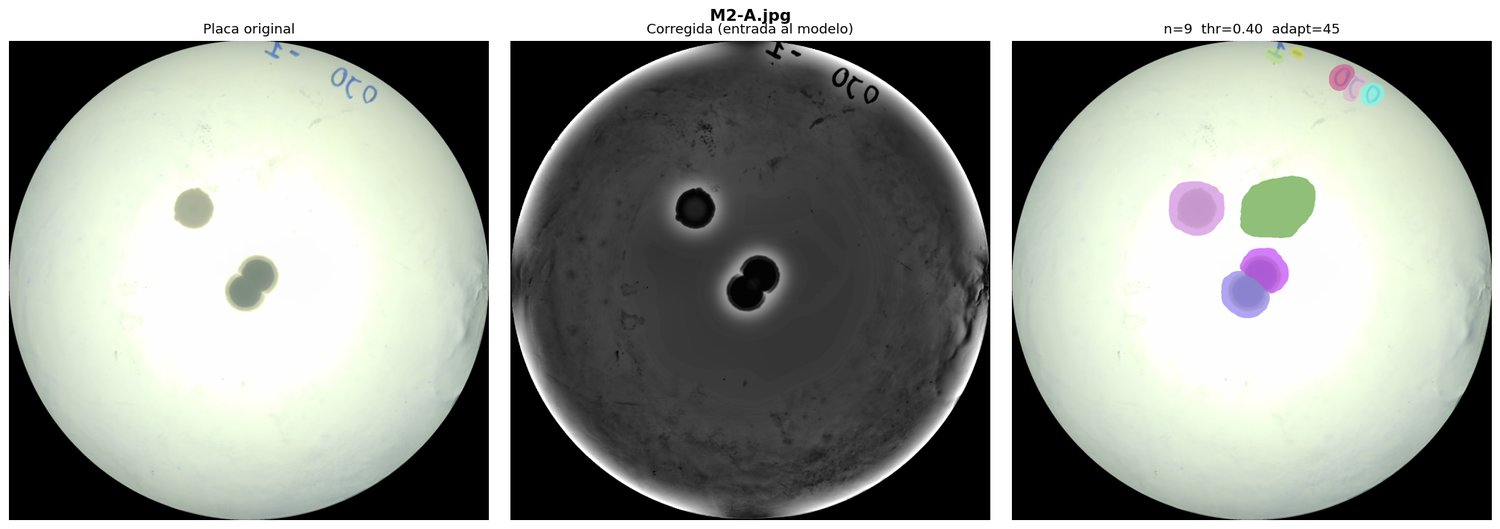

### M2-B, 1 colonias detectadas

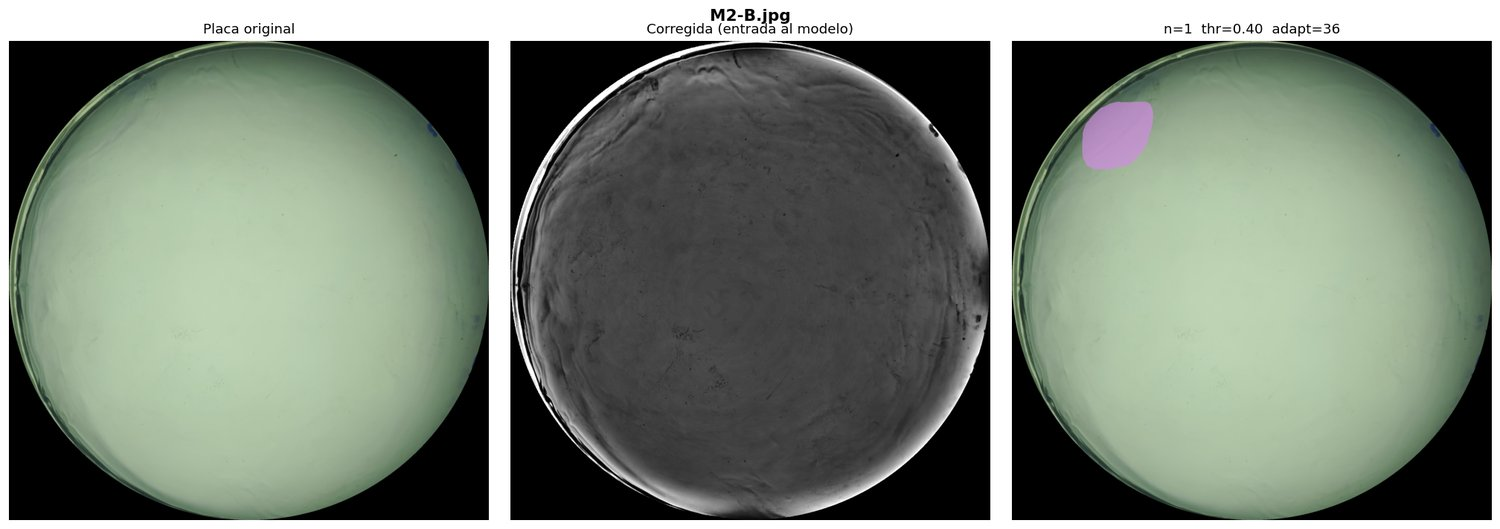

### M2-C, 3 colonias detectadas

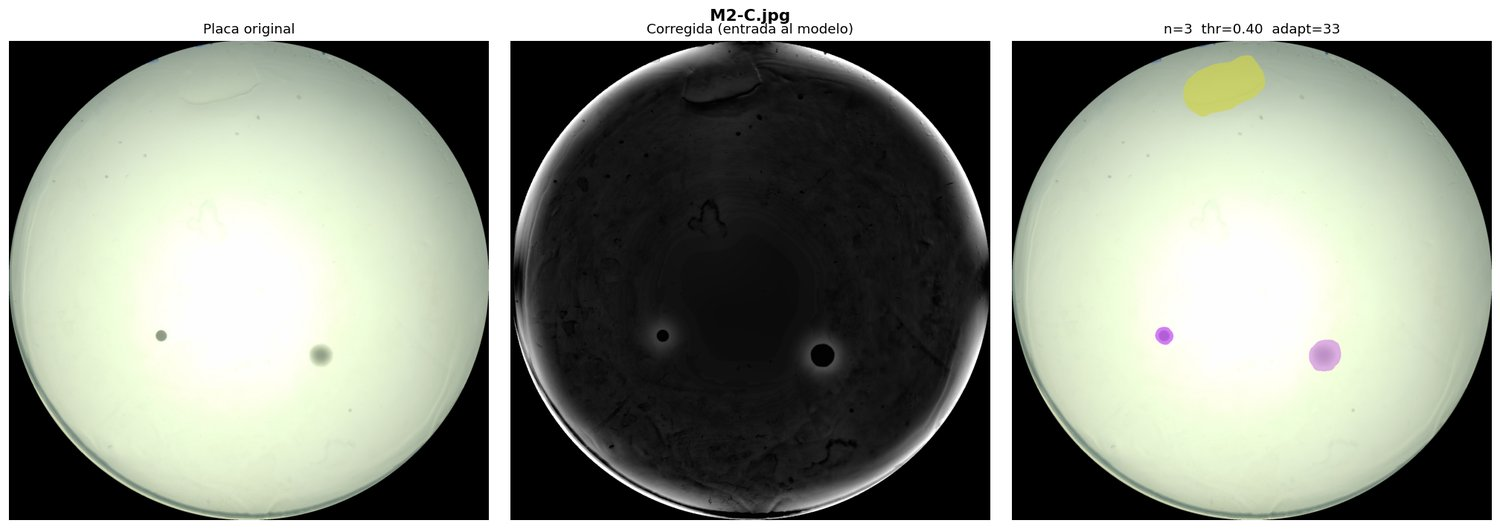

### MC73-A, 13 colonias detectadas

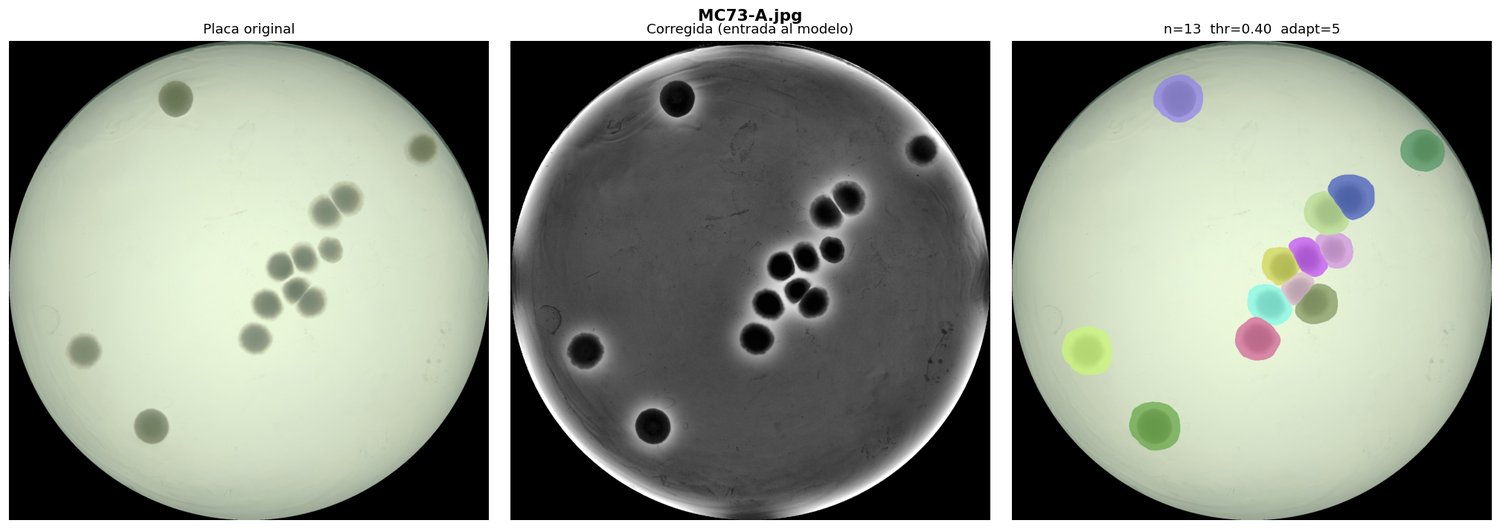

### MC73-B, 15 colonias detectadas

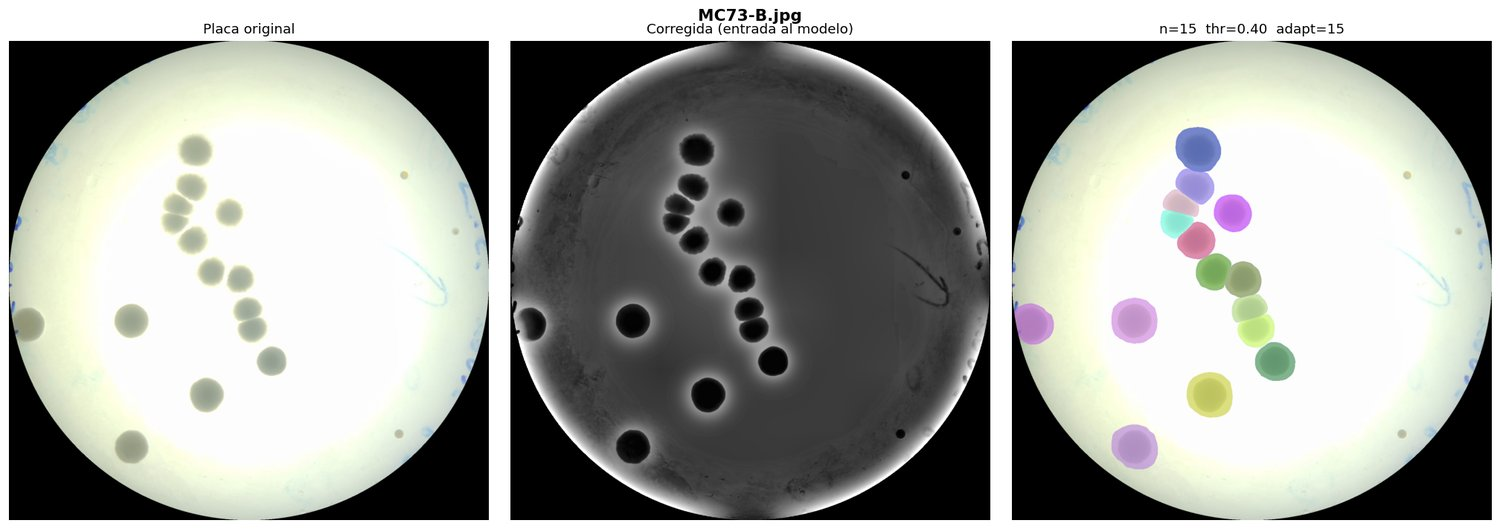

### MC73-C, 4 colonias detectadas

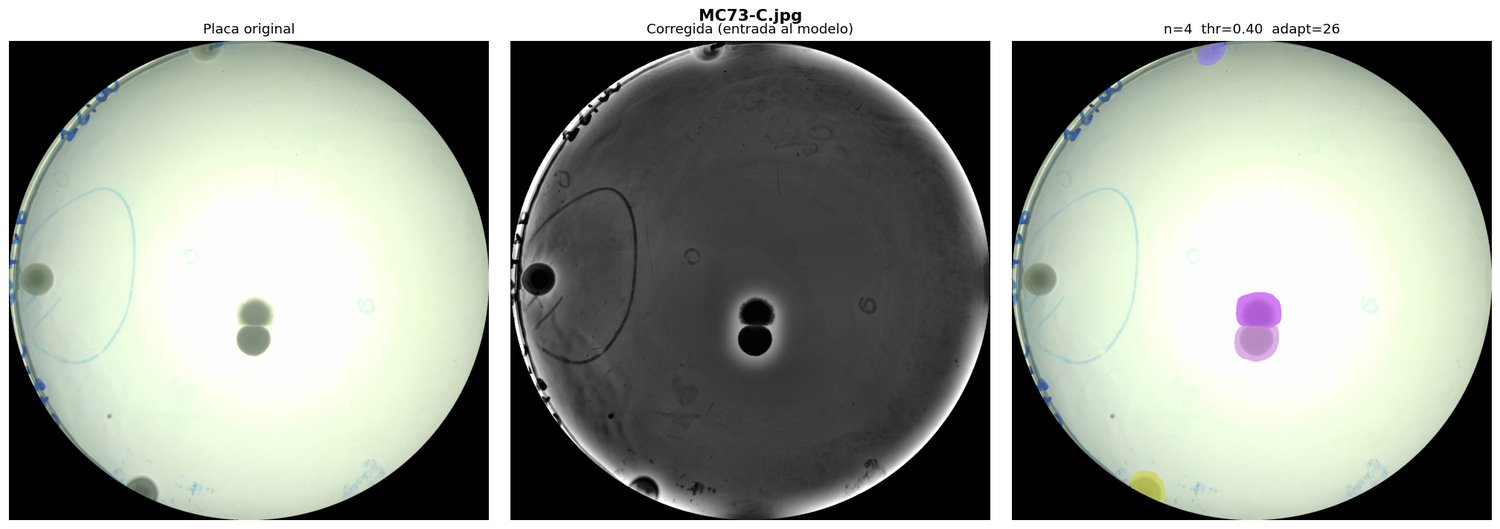

### MC73-D, 9 colonias detectadas

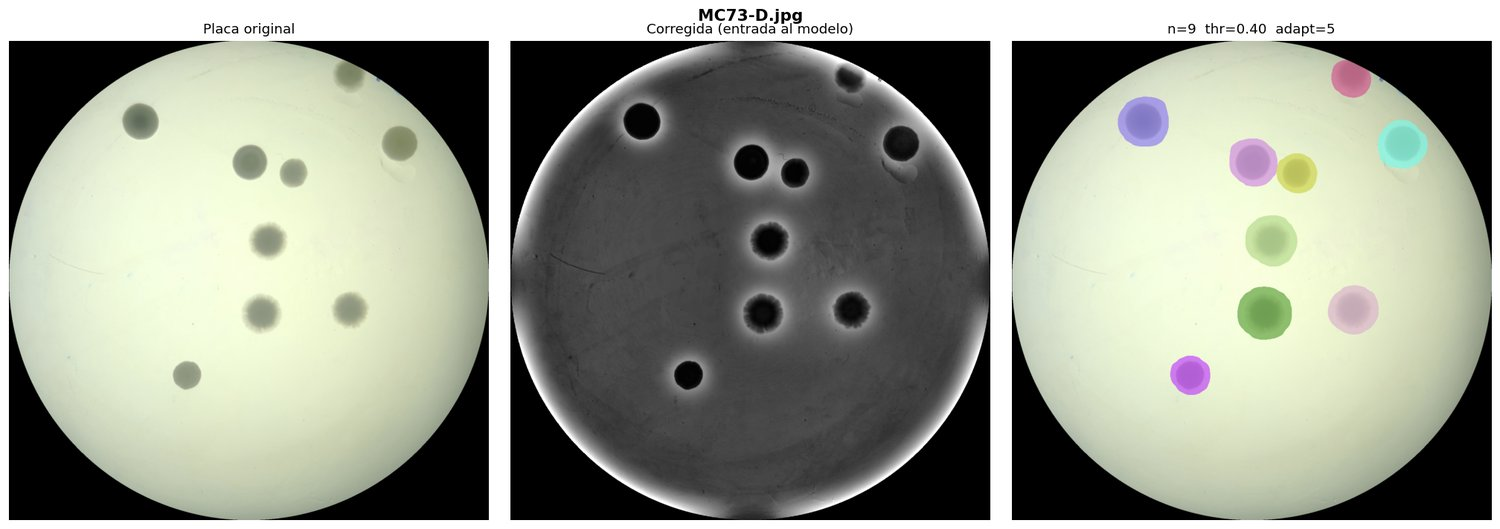

### RC73-A-2.5, 243 colonias detectadas

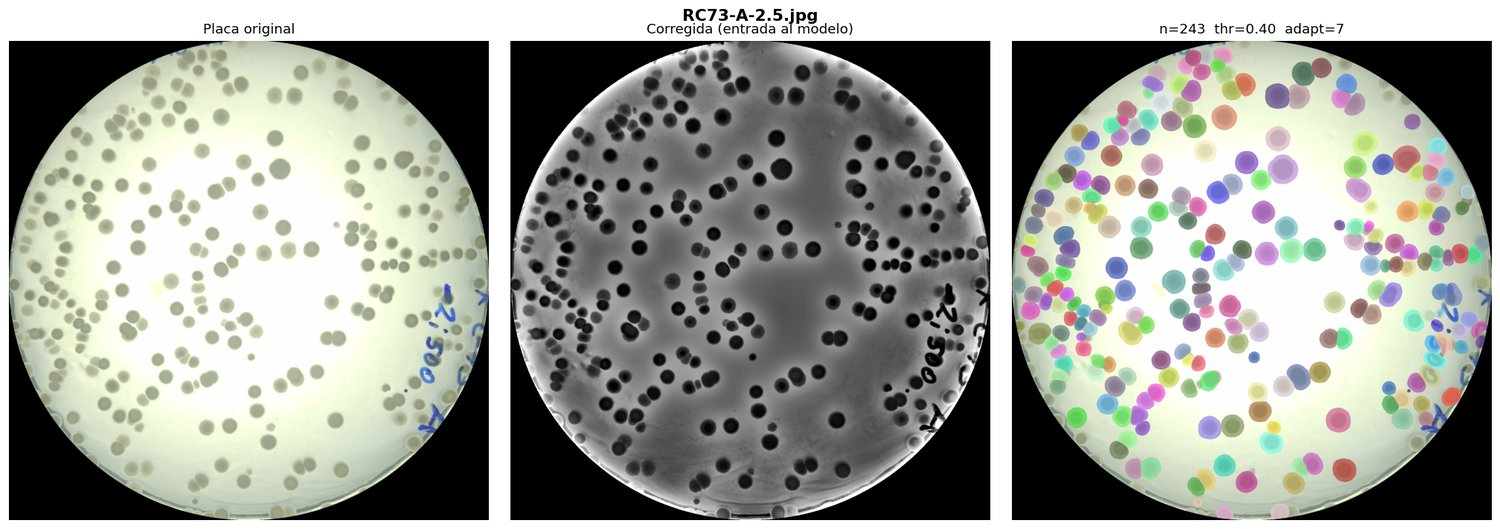

### RC73-A-3.1, 81 colonias detectadas

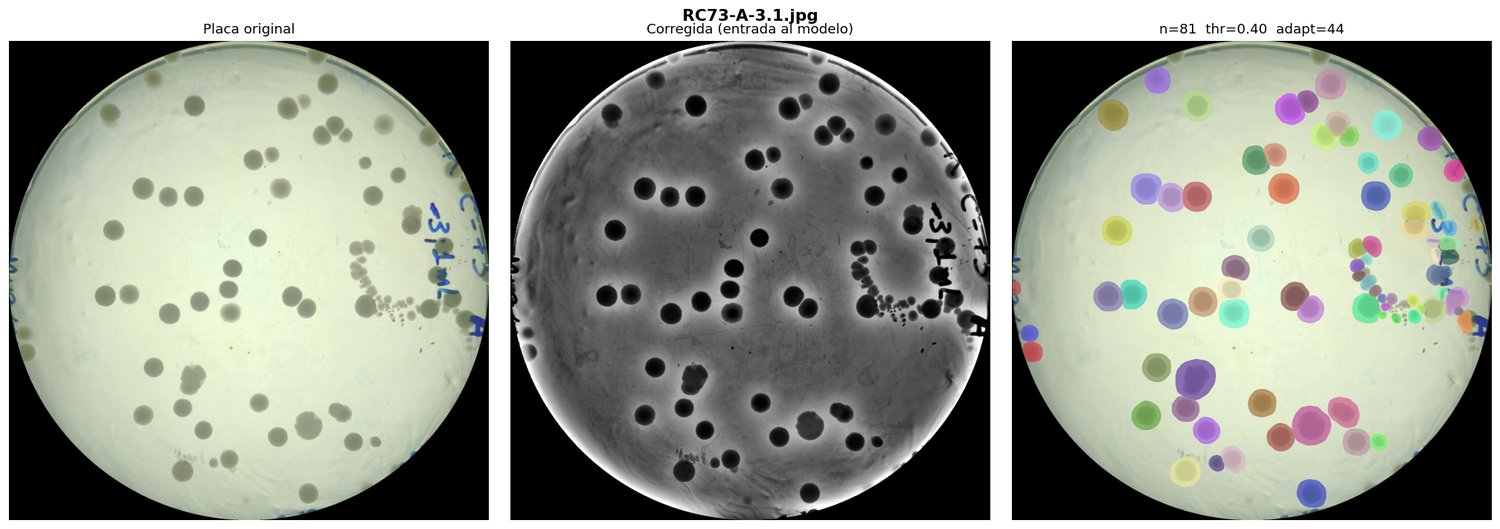

### RC73-B-2.5, 225 colonias detectadas

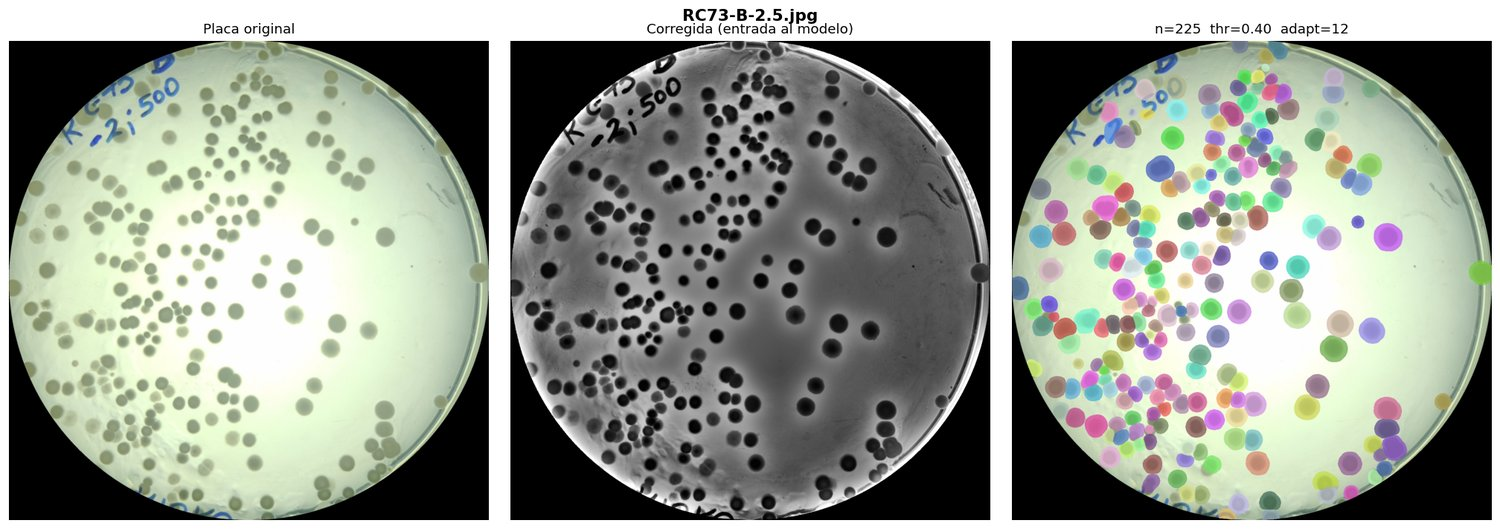

### RC73-B-3.1, 60 colonias detectadas

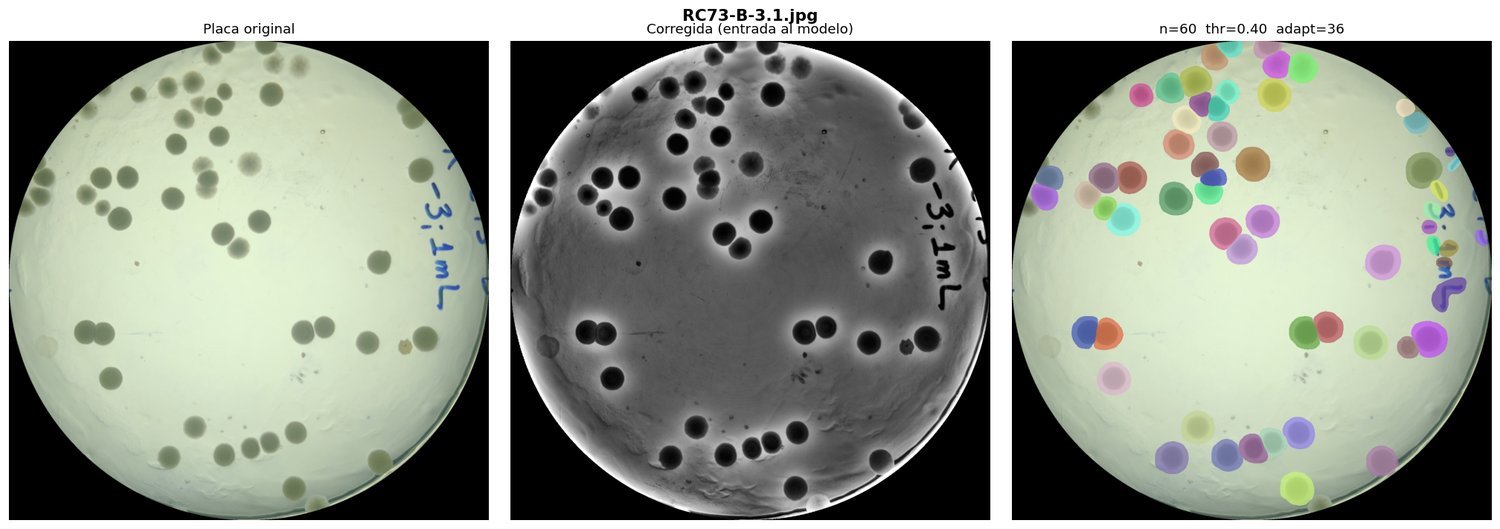

## 5. Limitaciones

Tres cosas quedan pendientes y conviene tenerlas presentes al leer los conteos.

**Sub-conteo en colonias pequeñas y palidas.** En las placas de la serie M2, donde las colonias forman cadenas de elementos muy pequeños y de bajo contraste, el conteo se queda corto. La correccion de iluminacion las hace visibles, como se aprecia en el panel central, pero CellSAM no genera una propuesta de deteccion para todas.

**La estimacion previa de densidad no funciona.** Se calibro sobre un conjunto de fotografias anterior y no transfiere a estas condiciones de captura. La columna scout de la tabla de resultados lo muestra sin ambiguedad, la placa RC73-A-2.5, que tiene 243 colonias, recibe una estimacion de 7, mientras que M1-B, que esta esteril, recibe 84. No es que el estimador sea impreciso, es que no guarda relacion con la densidad real, porque sobre el agar vacio amplifica el ruido y lo cuenta como estructura.

La consecuencia practica es que la seleccion adaptativa de umbral quedo inactiva y las quince placas se procesaron con umbral 0.40, con la unica excepcion de M1-B, que recibio 0.65 por una clasificacion equivocada. En ese caso no afecto al resultado porque la placa estaba esteril y el conteo fue cero de todos modos. Los conteos de esta tabla son por tanto los de un umbral fijo, no los de un pipeline adaptativo. Para que ese paso aporte algo habria que recalibrarlo sobre fotografias tomadas en estas mismas condiciones.

**Sin conteo manual de referencia.** No hay un conteo humano de estas quince placas contra el cual medir el error. Las validaciones hechas son visuales, revisando los paneles uno por uno, y en ese examen las placas de buen contraste resultan correctas, MC73-A con 13 y RC73-A-2.5 con 204. Para dar una cifra de exactitud haria falta contar manualmente al menos una parte del conjunto.